## IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from xgboost import XGBRegressor, XGBClassifier

## LOAD DATA

In [2]:
df = pd.read_csv("../data/insurance_cleaned.csv")

C:\Users\hp\AppData\Local\Temp\ipykernel_1724\1864962053.py:1: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/insurance_cleaned.csv")


## FEATURE ENGINEERING

In [3]:
# Convert dates
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])
df['VehicleIntroDate'] = pd.to_datetime(
    df['VehicleIntroDate'],
    errors='coerce'
)

# Vehicle Age
df['VehicleAge'] = (
    df['TransactionMonth'].dt.year -
    df['RegistrationYear']
)

# Policy Month
df['PolicyMonth'] = df['TransactionMonth'].dt.month

# Claim Indicator
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

## FEATURE SELECTION

In [4]:
features = [
    'Province',
    'PostalCode',
    'VehicleType',
    'make',
    'Model',
    'RegistrationYear',
    'VehicleAge',
    'kilowatts',
    'cubiccapacity',
    'NumberOfDoors',
    'CustomValueEstimate',
    'SumInsured',
    'Gender',
    'MaritalStatus',
    'CoverType',
    'TermFrequency',
    'CalculatedPremiumPerTerm'
]

## IDENTIFY COLUMN TYPES

In [5]:
categorical_cols = [
    'Province',
    'VehicleType',
    'make',
    'Model',
    'Gender',
    'MaritalStatus',
    'CoverType',
    'TermFrequency'
]

numerical_cols = [
    'PostalCode',
    'RegistrationYear',
    'VehicleAge',
    'kilowatts',
    'cubiccapacity',
    'NumberOfDoors',
    'CustomValueEstimate',
    'SumInsured',
    'CalculatedPremiumPerTerm'
]

## PREPROCESSING PIPELINE

In [6]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## PART 1 — CLAIM SEVERITY PREDICTION

In [7]:
# Only policies with claims
severity_df = df[df['TotalClaims'] > 0].copy()


X_severity = severity_df[features]
y_severity = severity_df['TotalClaims']

X_train_sev, X_test_sev, y_train_sev, y_test_sev = train_test_split(
    X_severity,
    y_severity,
    test_size=0.2,
    random_state=42
)

### MODELS

In [8]:
severity_models = {

    'Linear Regression':
        LinearRegression(),

    'Random Forest':
        RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),

    'XGBoost':
        XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42
        )
}

### TRAIN & EVALUATE

In [9]:
severity_results = []

for name, model in severity_models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train_sev, y_train_sev)

    predictions = pipeline.predict(X_test_sev)

    rmse = np.sqrt(mean_squared_error(y_test_sev, predictions))
    r2 = r2_score(y_test_sev, predictions)

    severity_results.append({
        'Model': name,
        'RMSE': rmse,
        'R2': r2
    })
    print(f"{name}")
    print("-----------------------------------")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}\n")

severity_results_df = pd.DataFrame(severity_results)

print("\nSeverity Model Results")
print(severity_results_df)


Linear Regression
-----------------------------------
RMSE: 33388.46
R²: 0.2172

Random Forest
-----------------------------------
RMSE: 32324.51
R²: 0.2663

XGBoost
-----------------------------------
RMSE: 32862.28
R²: 0.2417


Severity Model Results
               Model          RMSE        R2
0  Linear Regression  33388.464199  0.217209
1      Random Forest  32324.507793  0.266303
2            XGBoost  32862.277649  0.241688


## PART 2 — CLAIM PROBABILITY MODEL

In [10]:
X_class = df[features]
y_class = df['HasClaim']

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

## HANDLE CLASS IMBALANCE

In [11]:
# Calculate imbalance ratio for XGBoost
negative_class = (y_train_class == 0).sum()
positive_class = (y_train_class == 1).sum()

scale_pos_weight = negative_class / positive_class

print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

Scale Pos Weight: 359.20


### CLASSIFICATION MODELS

In [12]:
classification_models = {

    'Logistic Regression':
        LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=42
        ),

    'Random Forest':
        RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ),

    'XGBoost':
        XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric='logloss'
        )
}

### TRAIN & EVALUATE

In [13]:
classification_results = []

best_classifier_pipeline = None
best_f1 = 0

for name, model in classification_models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train model
    pipeline.fit(X_train_class, y_train_class)

    # Predictions
    predictions = pipeline.predict(X_test_class)

    # Metrics
    accuracy = accuracy_score(y_test_class, predictions)
    precision = precision_score(y_test_class, predictions, zero_division=0)
    recall = recall_score(y_test_class, predictions, zero_division=0)
    f1 = f1_score(y_test_class, predictions, zero_division=0)

    # Store results
    classification_results.append({
        'Model': name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

    # Print Results
    print(f"\n{name}")
    print("-----------------------------------")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}\n")

    print("Classification Report")
    print(classification_report(y_test_class, predictions))

    # Save best model based on F1-score
    if f1 > best_f1:
        best_f1 = f1
        best_classifier_pipeline = pipeline

# Create results dataframe
classification_results_df = pd.DataFrame(
    classification_results
)

# Sort by F1-score
classification_results_df = classification_results_df.sort_values(
    by='F1-Score',
    ascending=False
)

print("CLASSIFICATION MODEL COMPARISON")

print(classification_results_df)


Logistic Regression
-----------------------------------
Accuracy : 0.7446
Precision: 0.0103
Recall   : 0.9568
F1-Score : 0.0204

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.74      0.85    199355
           1       0.01      0.96      0.02       555

    accuracy                           0.74    199910
   macro avg       0.51      0.85      0.44    199910
weighted avg       1.00      0.74      0.85    199910


Random Forest
-----------------------------------
Accuracy : 0.7456
Precision: 0.0102
Recall   : 0.9477
F1-Score : 0.0203

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.74      0.85    199355
           1       0.01      0.95      0.02       555

    accuracy                           0.75    199910
   macro avg       0.51      0.85      0.44    199910
weighted avg       1.00      0.75      0.85    199910


XGBoost
-----------------------------------
Acc

## PART 3 — RISK-BASED PRICING FRAMEWORK

In [ ]:
preprocessor.fit(X_train_class)

# Transform datasets
X_train_class_processed = preprocessor.transform(X_train_class)
X_pricing_processed = preprocessor.transform(df[features])


# TRAIN FINAL CLASSIFIER MODEL


final_classifier_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

final_classifier_model.fit(
    X_train_class_processed,
    y_train_class
)


# TRAIN FINAL SEVERITY MODEL


X_train_sev_processed = preprocessor.transform(X_train_sev)

final_severity_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

final_severity_model.fit(
    X_train_sev_processed,
    y_train_sev
)


# PREDICT CLAIM PROBABILITY


claim_probability = final_classifier_model.predict_proba(
    X_pricing_processed
)[:, 1]


# PREDICT CLAIM SEVERITY


predicted_severity = final_severity_model.predict(
    X_pricing_processed
)

# Remove negative predictions
predicted_severity = np.maximum(predicted_severity, 0)


# PREMIUM CALCULATION


expense_loading = 500
profit_margin = 0.15

risk_premium = (
    claim_probability * predicted_severity
)

final_premium = (
    risk_premium +
    expense_loading +
    (risk_premium * profit_margin)
)

pricing_results = pd.DataFrame({
    'PredictedClaimProbability': claim_probability,
    'PredictedSeverity': predicted_severity,
    'RecommendedPremium': final_premium
})

print(pricing_results.head())



RISK-BASED PRICING
   PredictedClaimProbability  PredictedSeverity  RecommendedPremium
0                   0.708757        2385.913086         2444.688232
1                   0.708757        2385.913086         2444.688232
2                   0.708757        2385.913086         2444.688232
3                   0.728969       27612.779297        23648.183594
4                   0.728969       27612.779297        23648.183594


Generating SHAP Summary Plot...


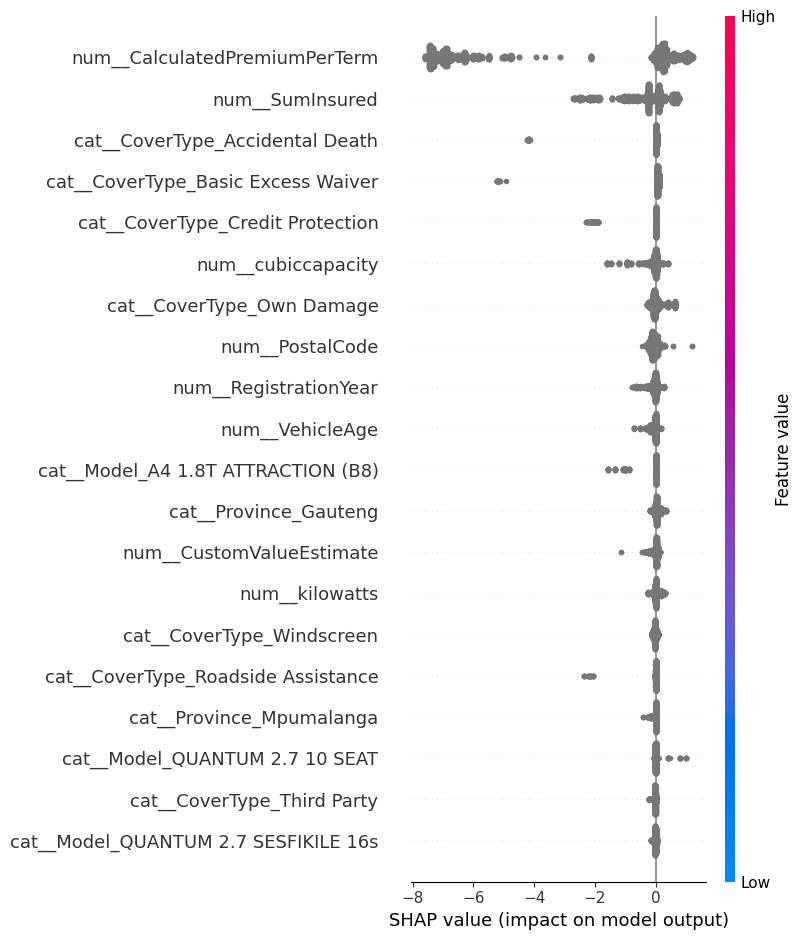


TOP 10 MOST IMPORTANT FEATURES
                                Feature  Importance
8         num__CalculatedPremiumPerTerm    3.716321
7                       num__SumInsured    0.594979
477     cat__CoverType_Accidental Death    0.135508
480  cat__CoverType_Basic Excess Waiver    0.135016
483    cat__CoverType_Credit Protection    0.132173
4                    num__cubiccapacity    0.113729
490           cat__CoverType_Own Damage    0.110068
0                       num__PostalCode    0.097454
1                 num__RegistrationYear    0.071231
2                       num__VehicleAge    0.069398


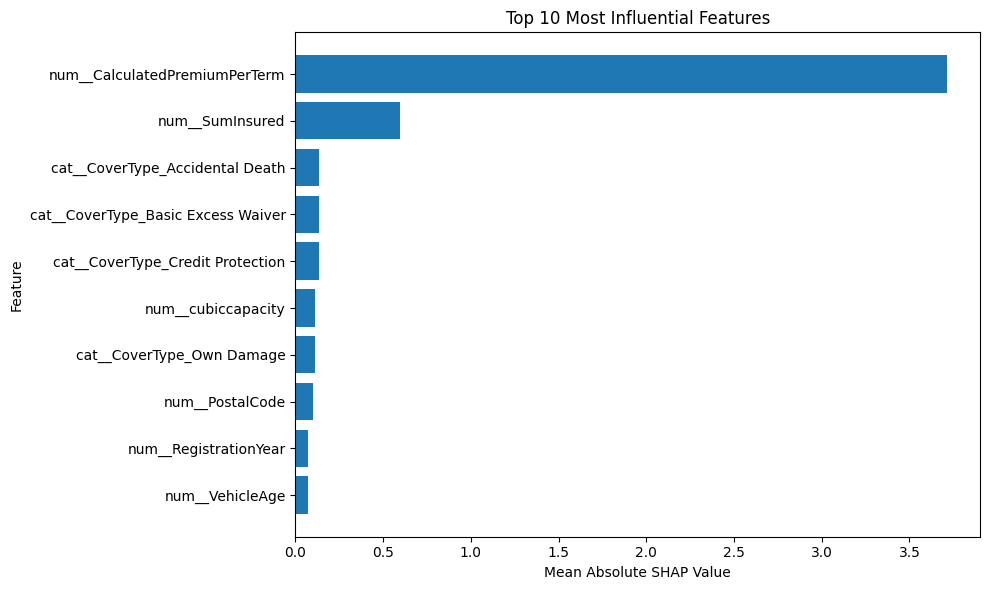

In [ ]:
encoded_feature_names = preprocessor.get_feature_names_out()


# SAMPLE DATA FOR SHAP

sample_size = 2000

X_sample = X_pricing_processed[:sample_size]


# CREATE SHAP EXPLAINER


explainer = shap.TreeExplainer(final_classifier_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)


# SHAP SUMMARY PLOT


print("Generating SHAP Summary Plot...")

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=encoded_feature_names
)


# TOP FEATURE IMPORTANCE TABLE


# Mean absolute SHAP values
importance = np.abs(shap_values).mean(axis=0)

feature_importance_df = pd.DataFrame({
    'Feature': encoded_feature_names,
    'Importance': importance
})

# Top 10 features
top_features = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

print("\nTOP 10 MOST IMPORTANT FEATURES")
print(top_features)


# BAR PLOT OF TOP FEATURES


plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 10 Most Influential Features")

plt.tight_layout()
plt.show()

### Business Interpretation of SHAP Feature Importance

The SHAP analysis identified the variables that most strongly influence predicted insurance risk and premium recommendations within the ACIS pricing framework.

1. **CalculatedPremiumPerTerm** emerged as the most influential feature in the model. Policies with higher existing premiums were consistently associated with higher predicted claim risk. This suggests that historical underwriting practices already capture meaningful risk patterns, and the machine learning model reinforces the validity of prior pricing decisions while refining them further.

2. **SumInsured** was the second most important driver of prediction outcomes. Higher insured values increased the predicted claim severity because more expensive vehicles typically result in larger repair or replacement costs. This indicates that insured vehicle value should remain a central component of premium pricing calculations.

3. Several **CoverType** categories — particularly *Accidental Death*, *Basic Excess Waiver*, *Credit Protection*, and *Own Damage* — showed strong influence on claim predictions. Policies containing these cover types were associated with higher expected losses, likely because they represent more comprehensive or higher-risk protection plans. From a business perspective, this suggests that specific add-on cover products materially increase insurer exposure and should carry differentiated pricing adjustments.

4. **Vehicle engine capacity (cubiccapacity)** significantly impacted predicted risk. Vehicles with larger engines tended to exhibit higher predicted claim severity. Larger-engine vehicles are often more expensive, faster, and costlier to repair, which increases financial liability for insurers. This provides evidence that engine size is an important underwriting variable for risk segmentation.

5. **PostalCode** was also an important predictor, indicating meaningful geographic variation in claim behavior. Certain geographic areas may experience higher accident frequency, theft rates, fraud exposure, or repair costs. This supports the introduction of region-sensitive premium adjustments and targeted marketing strategies for lower-risk areas.

6. **RegistrationYear** and **VehicleAge** both influenced the model, showing that older vehicles generally contribute to higher predicted claims. Older vehicles may have poorer safety systems, greater mechanical failure risk, and increased maintenance issues. This provides quantitative evidence for refining age-based pricing policies and depreciation-related premium adjustments.

### Business Recommendations

* Introduce more granular **risk-based pricing** using vehicle age, engine capacity, and geographic location as key segmentation variables.
* Apply differentiated premium loadings for high-risk **cover types** that historically contribute to elevated claim severity.
* Use **PostalCode-level insights** to guide both underwriting strategy and regional marketing campaigns targeting profitable low-risk segments.
* Continue leveraging historical premium patterns while integrating machine learning predictions to improve pricing precision and portfolio profitability.
* Consider offering premium discounts for newer vehicles and lower-risk regions to attract profitable customers during ACIS’s growth phase.
